***

# Lab 6 - Limiarização em Imagens

***

## 3.a) Limiarização (*Thresholding*) manual

In [6]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
!pip install scikit-image
from morph import *

mm.install()

In [7]:
img1 = io.imread("foto-grupo.jpeg")
img2 = io.imread("avatares.png")

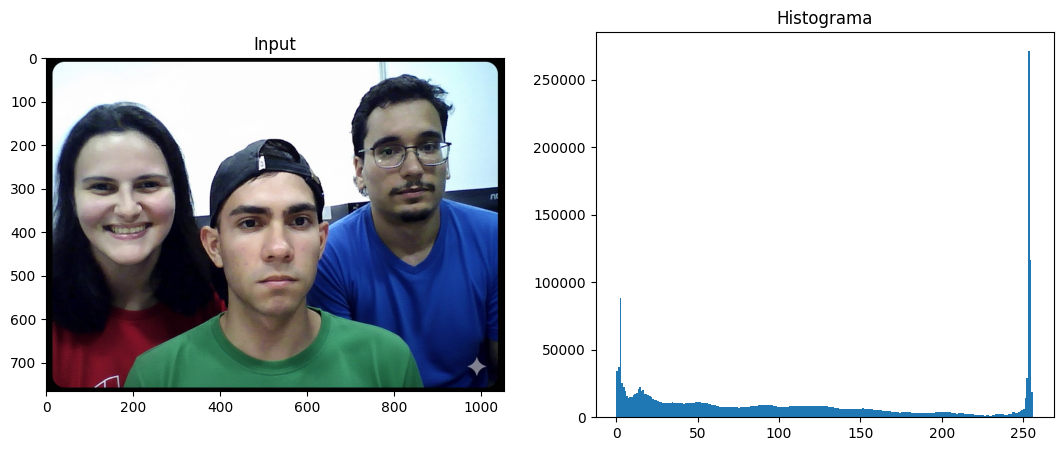

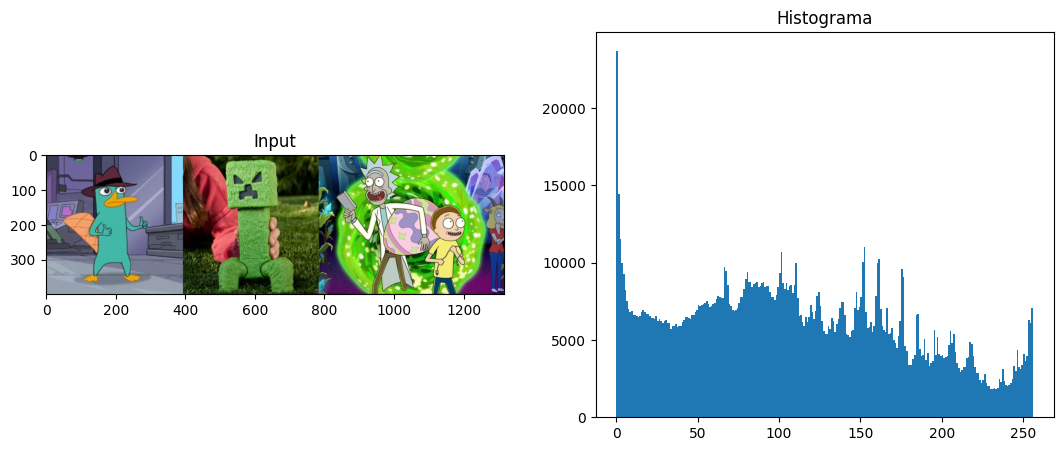

In [8]:
images = [img1, img2]

for img in images:
    plt.figure(figsize=(13,5))
    plt.subplot(121),plt.imshow(img,"gray"),plt.title('Input')
    plt.subplot(122),plt.hist(img.ravel(), bins=256, range=[0,256]),plt.title('Histograma')
    plt.show()

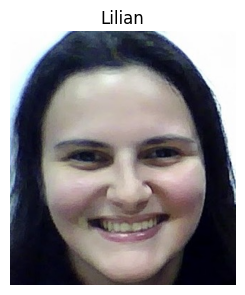

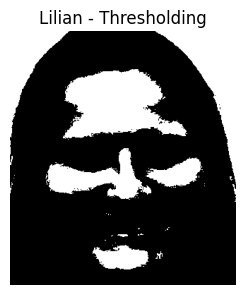

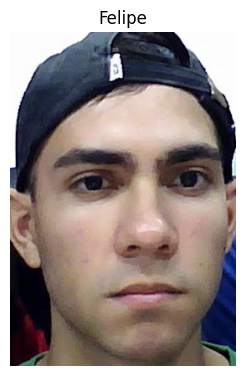

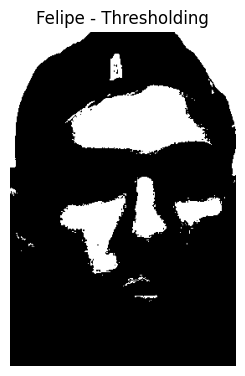

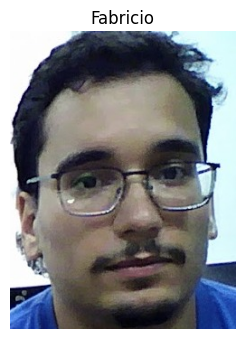

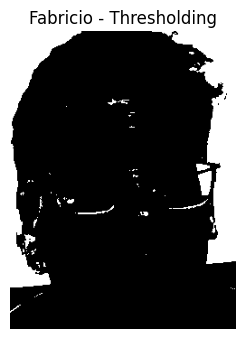

In [9]:
#LIMIARIZACAO MANUAL ROSTOS

h, w, c = img1.shape

av1 = img1[120:480, 20:340]
av2 = img1[200:600, 370:640]
av3 = img1[50:380, 700:950]

for img, name in [(av1,"Lilian"),(av2,"Felipe"),(av3,"Fabricio")]:
    plt.subplot(121),plt.imshow(img),plt.axis('off'),plt.title(name)
    plt.show()
    img_gray = cv2.cvtColor(img, cv2.COLOR_RGBA2GRAY)
    plt.subplot(121),plt.imshow(img_gray > 175, cmap='gray'),plt.axis('off'),plt.title(f"{name} - Thresholding")
    plt.show()


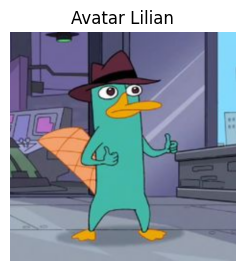

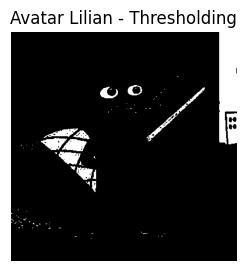

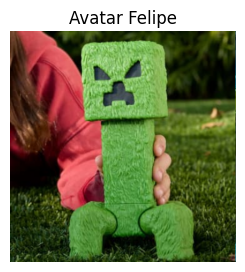

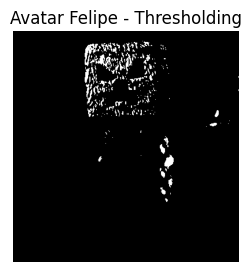

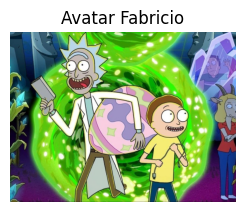

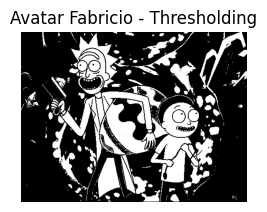

In [10]:
#LIMIARIZACAO MANUAL AVATARES

h, w, c = img2.shape
step = w // 3

av1 = img2[:, 0:393]
av2 = img2[:, 394:785]
av3 = img2[:, 786:w]

for img, name in [(av1,"Avatar Lilian"),(av2,"Avatar Felipe"),(av3,"Avatar Fabricio")]:
    plt.subplot(121),plt.imshow(img),plt.axis('off'),plt.title(name)
    plt.show()
    img_gray = cv2.cvtColor(img, cv2.COLOR_RGBA2GRAY)
    plt.subplot(121),plt.imshow(img_gray > 175, cmap='gray'),plt.axis('off'),plt.title(f"{name} - Thresholding")
    plt.show()  


## 3.a) Limiarização OTSU


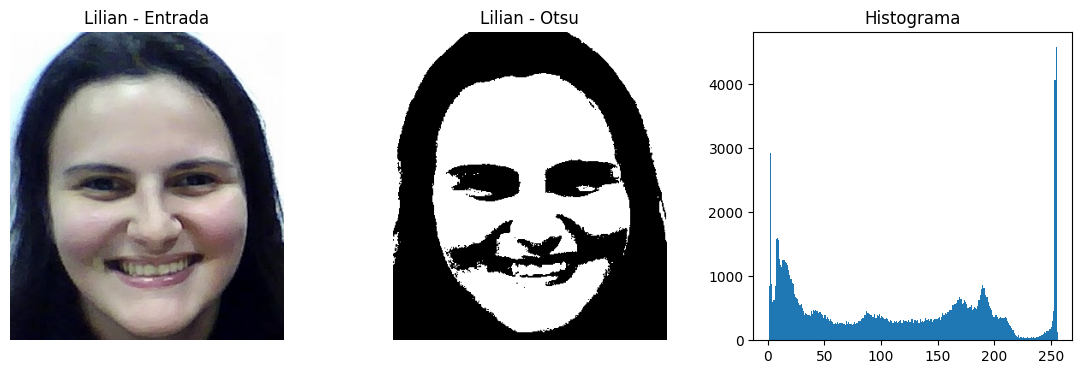

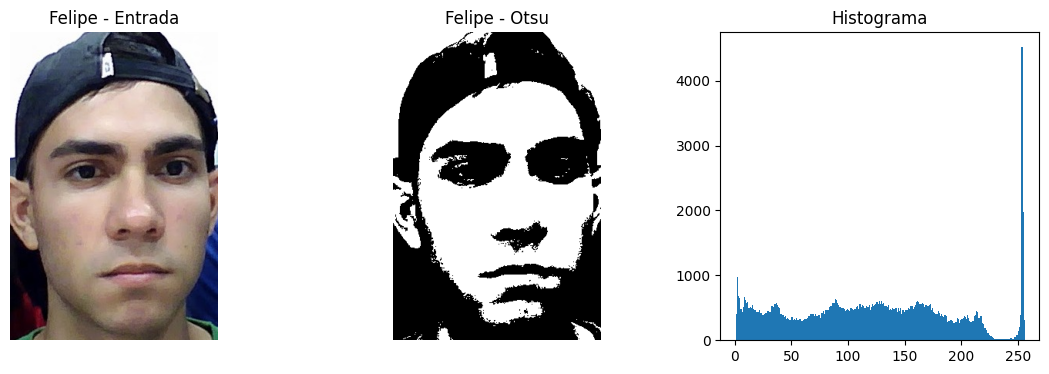

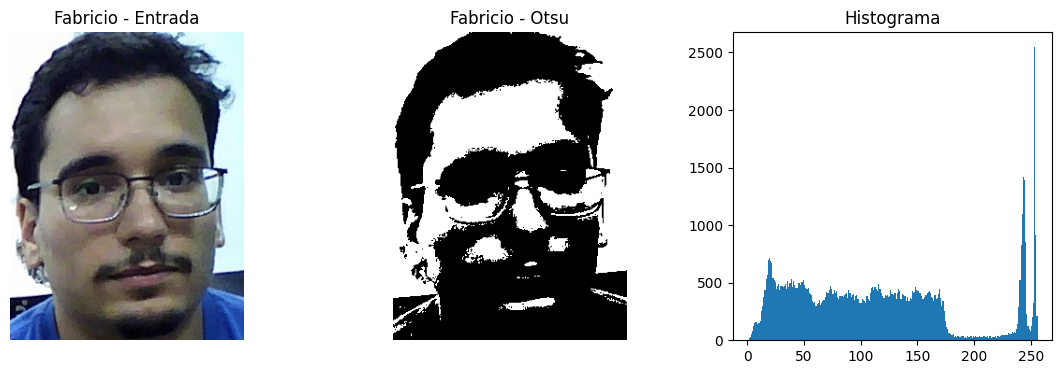

In [11]:
h, w, c = img1.shape

av1 = img1[120:480, 20:340]
av2 = img1[200:600, 370:640]
av3 = img1[50:380, 700:950]

for img, name in [(av1,"Lilian"),(av2,"Felipe"),(av3,"Fabricio")]:

    img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    limiar, otsu = cv2.threshold(img_gray, 0, 255,
                                 cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    plt.figure(figsize=(14,4))

    plt.subplot(131)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{name} - Entrada")

    plt.subplot(132)
    plt.imshow(otsu, cmap="gray")
    plt.axis('off')
    plt.title(f"{name} - Otsu")

    plt.subplot(133)
    plt.hist(img_gray.ravel(), bins=256, range=[0,256])
    plt.title("Histograma")

    plt.show()

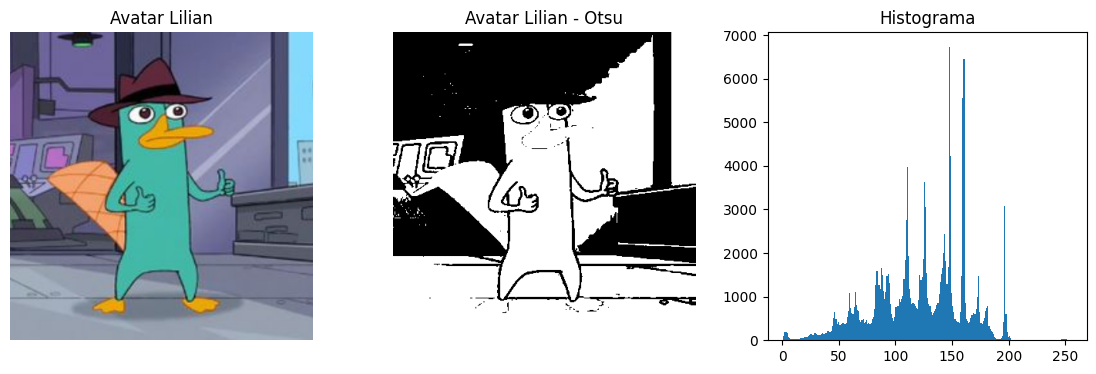

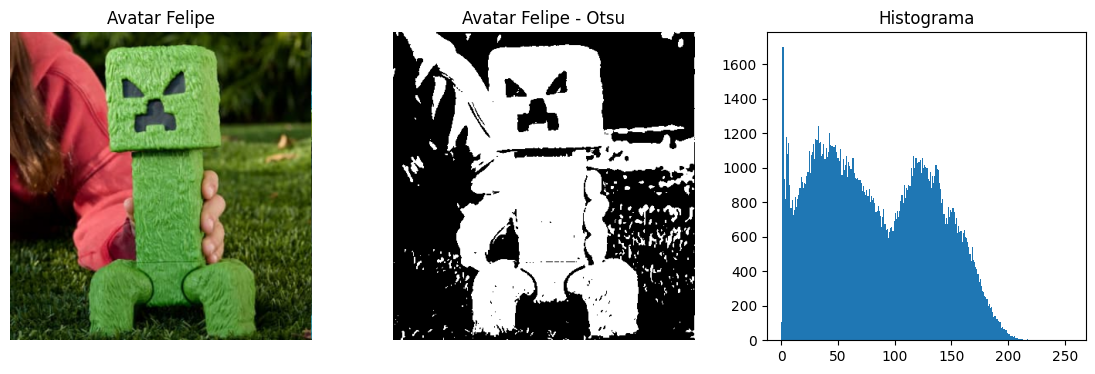

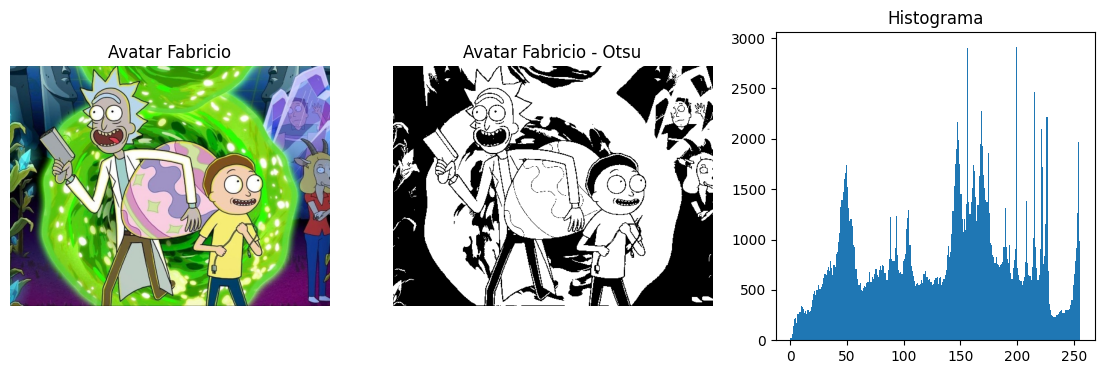

In [12]:
# LIMIARIZACAO OTSU AVATARES

h, w, c = img2.shape

av1 = img2[:, 0:393]
av2 = img2[:, 394:785]
av3 = img2[:, 786:w]

for img, name in [(av1,"Avatar Lilian"),(av2,"Avatar Felipe"),(av3,"Avatar Fabricio")]:

    img_gray = cv2.cvtColor(img, cv2.COLOR_RGBA2GRAY)
    limiar, otsu = cv2.threshold(
        img_gray, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    plt.figure(figsize=(14,4))

    plt.subplot(131)
    plt.imshow(img)
    plt.axis('off')
    plt.title(name)

    plt.subplot(132)
    plt.imshow(otsu, cmap='gray')
    plt.axis('off')
    plt.title(f"{name} - Otsu")

    plt.subplot(133)
    plt.hist(img_gray.ravel(), bins=256, range=[0,256])
    plt.title("Histograma")

    plt.show()

### 3.b) ELABORAÇÃO DE PROGRAMAS COM A WEBCAM:

In [13]:
import cv2 as cv
import numpy as np

cap = cv.VideoCapture(0)

width = int(cap.get(cv.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv.CAP_PROP_FRAME_HEIGHT))
fps = 20.0

fourcc = cv.VideoWriter_fourcc(*'XVID')
out = cv.VideoWriter('saida.avi', fourcc, fps, (width*2, height))

T = 100 
modo = "manual"

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        print("Erro ao capturar frame")
        break

    gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)

    if modo == "manual":
        _, th = cv.threshold(gray, T, 255, cv.THRESH_BINARY)

    elif modo == "otsu":
        _, th = cv.threshold(gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

    th_bgr = cv.cvtColor(th, cv.COLOR_GRAY2BGR)

    # juntar imagens lado a lado
    combined = np.hstack((frame, th_bgr))

    cv.putText(combined, f"Modo: {modo}", (20,40),
               cv.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

    if modo == "manual":
        cv.putText(combined, f"T = {T}", (20,80),
                   cv.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

    out.write(combined)

    cv.imshow("Original | Limiarizada", combined)

    key = cv.waitKey(1) & 0xFF

    if key == ord('q'):
        break

    elif key == ord('m'):
        modo = "manual"

    elif key == ord('o'):
        modo = "otsu"

    elif key == ord('u'):   # aumenta 
        T = min(255, T + 5)

    elif key == ord('d'):   # diminui 
        T = max(0, T - 5)

cap.release()
out.release()
cv.destroyAllWindows()

## 4) operações de limiarização nas imagens do trabalho final

In [14]:
def limiar_manual(img, T):
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    _, th = cv.threshold(gray, T, 255, cv.THRESH_BINARY)
    return th

def limiar_otsu(img):
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    _, th = cv.threshold(gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
    return th

def resultado(img, th_manual, th_otsu, titulo):
    
    plt.figure(figsize=(12,4))
    
    plt.subplot(1,3,1)
    plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title(f"{titulo} - Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(th_manual, cmap="gray")
    plt.title("Limiarização Manual")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(th_otsu, cmap="gray")
    plt.title("Limiarização Otsu")
    plt.axis("off")

    plt.show()

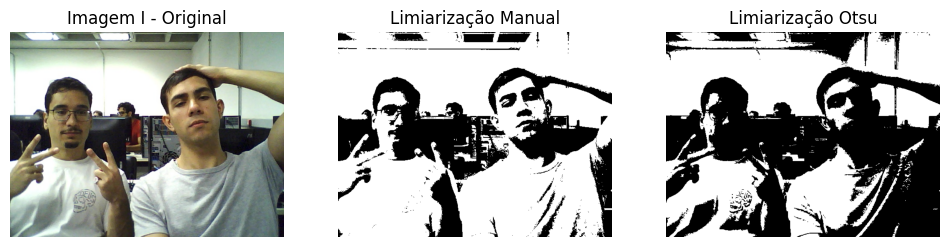

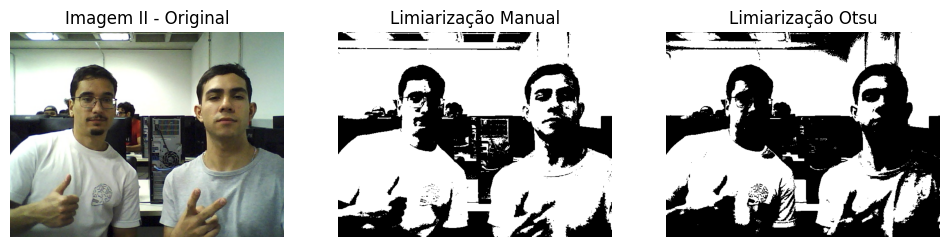

In [15]:
img1 = cv.imread("teste-para-projeto-I.jpg")
img2 = cv.imread("teste-para-projeto-II.jpg")

T = 100

th1_manual = limiar_manual(img1, T)
th1_otsu = limiar_otsu(img1)

th2_manual = limiar_manual(img2, T)
th2_otsu = limiar_otsu(img2)

resultado(img1, th1_manual, th1_otsu, "Imagem I")
resultado(img2, th2_manual, th2_otsu, "Imagem II")

## 5) Análise do Processamento de Limiarização

#### (5.a) Qual a diferença entre escolher o limiar olhando o histograma e usar métodos automáticos?

quando usamos a inspeção visual do histograma, a pessoa olha a distribuição dos níveis de cinza da imagem e escolhe manualmente um valor de limiar \(T\) que aparenta separar objeto e fundo, nos métodos automáticos, um algoritmo analisa o histograma e calcula o limiar sozinho, seguindo algum critério matemático. na inspeção visual temos como vantagem que permite maior precisao entendemos a imagem, e como desvantagem que variar entre cada caso, para metodos automaticos, temos que são consistentes e funcionam bem para processar muitas imagens, mas podem não funcionar bem quando o histograma não tem separação clara entre objeto e fundo.

Em resumo, a inspeção visual depende da decisão humana, enquanto os métodos automáticos usam cálculo para escolher o limiar.

#### (5.b) Por que usar \(T = 50\) ou \(T = 125\) pode gerar uma segmentação ruim na imagem `img2`?

O limiar define quais pixels viram objeto e quais viram fundo.para T = 50 (muito baixo) muitos pixels do fundo têm intensidade maior que 50, então acabam sendo classificados como objeto. A imagem fica com muito ruído, ja para T = 125 (muito alto) só pixels muito claros viram objeto. Partes do objeto podem acabar virando fundo.
Um caso ideal é escolher um valor entre os dois picos do histograma (fundo e objeto).  
No caso da `img2`, um valor por volta de **\(T \approx 90\)** tende a separar melhor as duas regiões.